In [1]:
# ============================================
# PROJECT 2: Late Delivery Risk Prediction
# Phase 6: Data Preparation for ML
# Author: Mohan | Unified Mentor Internship
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import joblib

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Load engineered dataset from Phase 5
df = pd.read_csv('../data/APL_Logistics_engineered.csv')

print(f"✅ Engineered dataset loaded")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst few columns: {df.columns[:10].tolist()}")

✅ Engineered dataset loaded
📊 Shape: 180,519 rows × 42 columns

First few columns: ['Type', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Name', 'Customer Country', 'Customer Segment', 'Department Name', 'Latitude']


In [2]:
# ===== INSPECT COLUMN TYPES =====
# Separate numeric vs categorical for proper handling

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"📊 NUMERIC COLUMNS ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"   • {col}")

print(f"\n📝 CATEGORICAL COLUMNS ({len(categorical_cols)}):")
for col in categorical_cols:
    n_unique = df[col].nunique()
    print(f"   • {col:<25} | {n_unique} unique values")

📊 NUMERIC COLUMNS (33):
   • Days for shipment (scheduled)
   • Benefit per order
   • Sales per customer
   • Late_delivery_risk
   • Latitude
   • Longitude
   • Order Item Discount
   • Order Item Discount Rate
   • Order Item Product Price
   • Order Item Profit Ratio
   • Order Item Quantity
   • Sales
   • Order Item Total
   • Order Profit Per Order
   • Product Price
   • Shipping_Pressure_Index
   • Mode_Risk_Score
   • Is_Express_Mode
   • Market_Risk_Score
   • Region_Risk_Score
   • Order_Complexity_Score
   • Is_High_Discount
   • Discount_Severity
   • Is_Loss_Order
   • Profit_Per_Unit
   • Profit_Margin
   • Sales_Category
   • Category_Risk_Score
   • Department_Risk_Score
   • Payment_Risk_Score
   • Is_Cash_Payment
   • Is_Transfer_Payment
   • Segment_Risk_Score

📝 CATEGORICAL COLUMNS (9):
   • Type                      | 4 unique values
   • Category Name             | 50 unique values
   • Customer Country          | 2 unique values
   • Customer Segment          

In [3]:
# ===== DROP COLUMNS NOT NEEDED FOR ML =====
# We replaced these with target-encoded risk scores in Phase 5
# Keeping them as one-hot would be redundant AND slow training

columns_to_drop = [
    # Replaced by Market_Risk_Score
    'Market',
    # Replaced by Region_Risk_Score
    'Order Region',
    # Replaced by Mode_Risk_Score
    'Shipping Mode',
    # Replaced by Category_Risk_Score
    'Category Name',
    # Replaced by Department_Risk_Score
    'Department Name',
    # Replaced by Payment_Risk_Score
    'Type',
    # Replaced by Segment_Risk_Score
    'Customer Segment',
    # Too many unique values, not useful
    'Customer Country',
    'Order Country',
]

# Safety: only drop columns that exist
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

print("🗑️ Dropping columns (replaced by target-encoded versions):")
for col in columns_to_drop:
    print(f"   ❌ {col}")

df_model = df.drop(columns=columns_to_drop)

print(f"\n✅ Shape after dropping: {df_model.shape}")

🗑️ Dropping columns (replaced by target-encoded versions):
   ❌ Market
   ❌ Order Region
   ❌ Shipping Mode
   ❌ Category Name
   ❌ Department Name
   ❌ Type
   ❌ Customer Segment
   ❌ Customer Country
   ❌ Order Country

✅ Shape after dropping: (180519, 33)


In [4]:
# ===== ENCODE ANY REMAINING CATEGORICAL COLUMNS =====
# After dropping target-encoded ones, check what's left

remaining_categorical = df_model.select_dtypes(include=['object']).columns.tolist()

print(f"Remaining categorical columns: {len(remaining_categorical)}")
if remaining_categorical:
    for col in remaining_categorical:
        n_unique = df_model[col].nunique()
        print(f"   • {col}: {n_unique} unique values")
    
    # If any remain, label-encode them (simple integer mapping)
    for col in remaining_categorical:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        print(f"   ✅ Label-encoded: {col}")
else:
    print("✅ All categorical columns already handled in Phase 5!")

# Verify
print(f"\nAll columns are now numeric: {df_model.select_dtypes(include=['object']).shape[1] == 0}")
print(f"Final shape: {df_model.shape}")

Remaining categorical columns: 0
✅ All categorical columns already handled in Phase 5!

All columns are now numeric: True
Final shape: (180519, 33)


In [5]:
# ===== SEPARATE X AND y =====
# X = features (what we use to predict)
# y = target (what we're predicting)

# Final safety check: ensure no remaining leakage columns
leakage_check = ['Days for shipping (real)', 'Delivery Status', 'Order Status']
present_leakage = [col for col in leakage_check if col in df_model.columns]

if present_leakage:
    print(f"🚨 WARNING: Leakage columns still present: {present_leakage}")
    df_model = df_model.drop(columns=present_leakage)
    print("✅ Dropped them.")
else:
    print("✅ No data leakage columns present. Safe to proceed.")

y = df_model['Late_delivery_risk']
X = df_model.drop(columns=['Late_delivery_risk'])

print(f"\n📊 X shape (features): {X.shape}")
print(f"🎯 y shape (target):   {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\n📈 Class balance: {y.mean()*100:.2f}% late, {(1-y.mean())*100:.2f}% on-time")

✅ No data leakage columns present. Safe to proceed.

📊 X shape (features): (180519, 32)
🎯 y shape (target):   (180519,)

Target distribution:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

📈 Class balance: 54.83% late, 45.17% on-time


In [6]:
# ===== SPLIT INTO TRAIN AND TEST SETS =====
# 80% for training the model
# 20% for testing (model never sees this until evaluation)
# stratify=y ensures both sets have same late/on-time ratio

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,    # For reproducibility (anyone running this gets same result)
    stratify=y          # Maintain class balance in both sets
)

print("✅ Data split complete!")
print(f"\n📊 TRAINING SET:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   Class balance: {y_train.mean()*100:.2f}% late")

print(f"\n📊 TEST SET:")
print(f"   X_test:  {X_test.shape}")
print(f"   y_test:  {y_test.shape}")
print(f"   Class balance: {y_test.mean()*100:.2f}% late")

print(f"\n💡 Why stratify? Without it, your test set might be 70% late/30% on-time")
print("   which would make evaluation misleading.")

✅ Data split complete!

📊 TRAINING SET:
   X_train: (144415, 32)
   y_train: (144415,)
   Class balance: 54.83% late

📊 TEST SET:
   X_test:  (36104, 32)
   y_test:  (36104,)
   Class balance: 54.83% late

💡 Why stratify? Without it, your test set might be 70% late/30% on-time
   which would make evaluation misleading.


In [7]:
# ===== SCALE FEATURES USING StandardScaler =====
# Why? Logistic Regression is sensitive to feature scale
# A feature ranging 0-1000 dominates a feature ranging 0-1
# StandardScaler centers each feature: mean=0, std=1

# CRITICAL: Fit ONLY on training data!
# Then transform both train and test using same scaler
# This prevents test data from leaking into preprocessing

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only — uses train's mean/std

# Convert back to DataFrames (easier to read)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✅ Scaling complete!")
print(f"\nBefore scaling — X_train['Sales'].mean(): {X_train['Sales'].mean():.2f}")
print(f"After scaling  — X_train_scaled['Sales'].mean(): {X_train_scaled['Sales'].mean():.4f}")
print(f"After scaling  — X_train_scaled['Sales'].std():  {X_train_scaled['Sales'].std():.4f}")

# Save the scaler — we need it in production (for Streamlit predictions)
joblib.dump(scaler, '../models/scaler.pkl')
print("\n✅ Scaler saved to: models/scaler.pkl")

✅ Scaling complete!

Before scaling — X_train['Sales'].mean(): 203.82
After scaling  — X_train_scaled['Sales'].mean(): 0.0000
After scaling  — X_train_scaled['Sales'].std():  1.0000

✅ Scaler saved to: models/scaler.pkl


In [8]:
# ===== APPLY SMOTE TO BALANCE CLASSES =====
# SMOTE = Synthetic Minority Over-sampling Technique
# Creates synthetic examples of the minority class
# Note: Our data is 55/45 — moderately imbalanced
# SMOTE is optional here but project doc mentions it

print("📊 BEFORE SMOTE:")
print(f"   Class 0 (on-time): {(y_train == 0).sum():,}")
print(f"   Class 1 (late):    {(y_train == 1).sum():,}")
print(f"   Ratio: {(y_train == 1).sum() / (y_train == 0).sum():.2f}")

# Apply SMOTE only to training set!
# Never apply SMOTE to test set — it must reflect real-world distribution
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("\n📊 AFTER SMOTE:")
print(f"   Class 0 (on-time): {(y_train_balanced == 0).sum():,}")
print(f"   Class 1 (late):    {(y_train_balanced == 1).sum():,}")
print(f"   New training shape: {X_train_balanced.shape}")

print("\n💡 SMOTE creates synthetic minority class examples")
print("💡 Test set unchanged — it represents real-world distribution")


📊 BEFORE SMOTE:
   Class 0 (on-time): 65,234
   Class 1 (late):    79,181
   Ratio: 1.21


  File "C:\Users\orchu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\orchu\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\orchu\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\orchu\anaconda3\Lib\subprocess.


📊 AFTER SMOTE:
   Class 0 (on-time): 79,181
   Class 1 (late):    79,181
   New training shape: (158362, 32)

💡 SMOTE creates synthetic minority class examples
💡 Test set unchanged — it represents real-world distribution


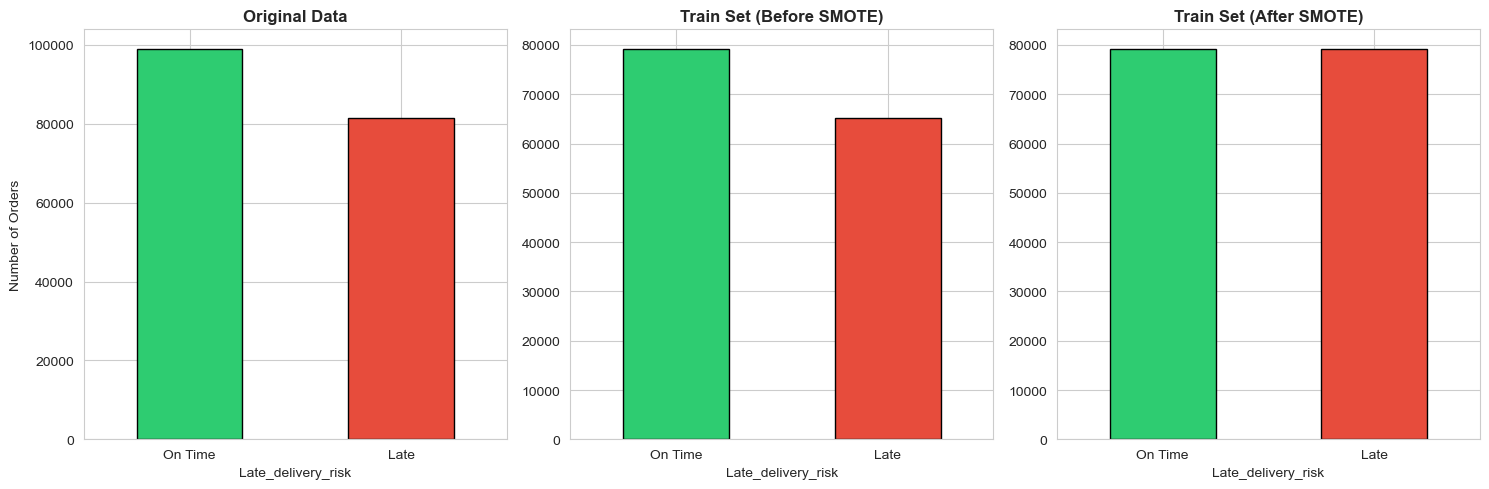


✅ Chart saved: charts/15_train_test_split.png


In [9]:
# ===== VISUALIZE THE SPLIT =====

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
y.value_counts().plot(kind='bar', ax=axes[0], 
                       color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Original Data', fontweight='bold')
axes[0].set_xticklabels(['On Time', 'Late'], rotation=0)
axes[0].set_ylabel('Number of Orders')

# After train/test split (train shown)
y_train.value_counts().plot(kind='bar', ax=axes[1],
                              color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Train Set (Before SMOTE)', fontweight='bold')
axes[1].set_xticklabels(['On Time', 'Late'], rotation=0)

# After SMOTE
pd.Series(y_train_balanced).value_counts().plot(kind='bar', ax=axes[2],
                              color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[2].set_title('Train Set (After SMOTE)', fontweight='bold')
axes[2].set_xticklabels(['On Time', 'Late'], rotation=0)

plt.tight_layout()
plt.savefig('../charts/15_train_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved: charts/15_train_test_split.png")

In [10]:
# ===== SAVE ALL PREPARED DATASETS =====
# We'll load these directly in Phase 7 (modeling)

# Save numpy/pandas-friendly format
joblib.dump(X_train_balanced, '../models/X_train_balanced.pkl')
joblib.dump(X_test_scaled, '../models/X_test_scaled.pkl')
joblib.dump(y_train_balanced, '../models/y_train_balanced.pkl')
joblib.dump(y_test, '../models/y_test.pkl')

# Save feature names for later use in Streamlit
feature_names = X.columns.tolist()
joblib.dump(feature_names, '../models/feature_names.pkl')

print("✅ All prepared data saved to models/ folder:")
print("   • X_train_balanced.pkl  (training features, SMOTE-balanced)")
print("   • X_test_scaled.pkl     (test features, scaled)")
print("   • y_train_balanced.pkl  (training target)")
print("   • y_test.pkl            (test target)")
print("   • feature_names.pkl     (column names for Streamlit)")
print("   • scaler.pkl            (already saved)")

✅ All prepared data saved to models/ folder:
   • X_train_balanced.pkl  (training features, SMOTE-balanced)
   • X_test_scaled.pkl     (test features, scaled)
   • y_train_balanced.pkl  (training target)
   • y_test.pkl            (test target)
   • feature_names.pkl     (column names for Streamlit)
   • scaler.pkl            (already saved)


In [11]:
# ===== SANITY CHECK BEFORE MODELING =====

print("="*60)
print("PRE-MODELING SANITY CHECK")
print("="*60)

# Check shapes
print(f"\n📊 SHAPES:")
print(f"   X_train_balanced: {X_train_balanced.shape}")
print(f"   y_train_balanced: {y_train_balanced.shape}")
print(f"   X_test_scaled:    {X_test_scaled.shape}")
print(f"   y_test:           {y_test.shape}")

# Check for NaN
print(f"\n🔍 NaN CHECK:")
print(f"   X_train_balanced NaN: {pd.DataFrame(X_train_balanced).isnull().sum().sum()}")
print(f"   X_test_scaled NaN:    {X_test_scaled.isnull().sum().sum()}")
print(f"   y NaN:                {pd.Series(y_train_balanced).isnull().sum()}")

# Check for inf
print(f"\n🔍 INFINITY CHECK:")
print(f"   X_train_balanced inf: {np.isinf(X_train_balanced).sum().sum()}")
print(f"   X_test_scaled inf:    {np.isinf(X_test_scaled.values).sum()}")

# Check target balance
print(f"\n🎯 TARGET BALANCE:")
print(f"   Train (post-SMOTE): {pd.Series(y_train_balanced).value_counts().to_dict()}")
print(f"   Test (real-world):  {y_test.value_counts().to_dict()}")

print(f"\n✅ ALL SYSTEMS GO FOR PHASE 7 (MODELING)!")

PRE-MODELING SANITY CHECK

📊 SHAPES:
   X_train_balanced: (158362, 32)
   y_train_balanced: (158362,)
   X_test_scaled:    (36104, 32)
   y_test:           (36104,)

🔍 NaN CHECK:
   X_train_balanced NaN: 0
   X_test_scaled NaN:    0
   y NaN:                0

🔍 INFINITY CHECK:
   X_train_balanced inf: 0
   X_test_scaled inf:    0

🎯 TARGET BALANCE:
   Train (post-SMOTE): {1: 79181, 0: 79181}
   Test (real-world):  {1: 19796, 0: 16308}

✅ ALL SYSTEMS GO FOR PHASE 7 (MODELING)!


In [12]:
# Save phase 6 summary
summary = f"""
PHASE 6 SUMMARY — Data Preparation Complete
==============================================
INPUT:  APL_Logistics_engineered.csv (42 columns)

STEPS COMPLETED:
1. ✅ Dropped 9 redundant categorical columns (replaced by risk scores)
2. ✅ Separated features (X) and target (y)
3. ✅ Train-test split: 80/20, stratified
4. ✅ Standard scaling fit on train only (applied to test)
5. ✅ SMOTE applied to training set (test set untouched)

OUTPUT SHAPES:
   X_train_balanced: {X_train_balanced.shape}
   y_train_balanced: {y_train_balanced.shape}
   X_test_scaled:    {X_test_scaled.shape}
   y_test:           {y_test.shape}

FEATURE COUNT: {X.shape[1]} predictive features
TRAINING SAMPLES: {X_train_balanced.shape[0]:,} (post-SMOTE)
TEST SAMPLES: {X_test_scaled.shape[0]:,}

FILES SAVED:
   models/X_train_balanced.pkl
   models/X_test_scaled.pkl
   models/y_train_balanced.pkl
   models/y_test.pkl
   models/scaler.pkl
   models/feature_names.pkl

CRITICAL PRACTICES FOLLOWED:
- Fit scaler ONLY on training data (prevents leakage)
- Applied SMOTE ONLY on training data (test reflects reality)
- Stratified split (maintains class balance)
- Set random_state for reproducibility

READY FOR: Phase 7 — Model Building
"""
print(summary)

with open('../phase6_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)
print("\n✅ Saved to phase6_summary.txt")


PHASE 6 SUMMARY — Data Preparation Complete
INPUT:  APL_Logistics_engineered.csv (42 columns)

STEPS COMPLETED:
1. ✅ Dropped 9 redundant categorical columns (replaced by risk scores)
2. ✅ Separated features (X) and target (y)
3. ✅ Train-test split: 80/20, stratified
4. ✅ Standard scaling fit on train only (applied to test)
5. ✅ SMOTE applied to training set (test set untouched)

OUTPUT SHAPES:
   X_train_balanced: (158362, 32)
   y_train_balanced: (158362,)
   X_test_scaled:    (36104, 32)
   y_test:           (36104,)

FEATURE COUNT: 32 predictive features
TRAINING SAMPLES: 158,362 (post-SMOTE)
TEST SAMPLES: 36,104

FILES SAVED:
   models/X_train_balanced.pkl
   models/X_test_scaled.pkl
   models/y_train_balanced.pkl
   models/y_test.pkl
   models/scaler.pkl
   models/feature_names.pkl

CRITICAL PRACTICES FOLLOWED:
- Fit scaler ONLY on training data (prevents leakage)
- Applied SMOTE ONLY on training data (test reflects reality)
- Stratified split (maintains class balance)
- Set rand